# 04 · Cold start: onboarding a model the pool has never seen

Notebook 03 found that nearly all recoverable decay comes from access to new models. So
this is the mechanism that matters most, and it is Contribution 2's territory.

RollingBench §8.6 warm-starts a new model by blending an IRT ability estimate with a
low-rank matrix completion, "down-weighted by a confidence factor" that the document
never writes down. Contribution 2 (§5) replaces that with one conjugate Bayesian step:
no free parameter, and a closed-form prediction of how many probe items a model needs as
a function of how well the existing pool explains it.

That derivation rests on a bridge — §5.1's assumption that the low-rank item factors are
approximately linear in the same feature map. The proposal is emphatic that checking it
comes first: *"Run it first; if the bridge doesn't hold, that contribution needs rework
or drops from the paper before more time is spent on it."*

So: the bridge, then the sample complexity.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

## 7.4 — the precondition

Fit Φ once on the existing pool by regressing each model's known low-rank column onto its
known feature-space weights, and measure the residual. If a single Φ carries all eleven
models, the bridge holds.

In [2]:
cs = load("coldstart"); b = cs["bridge"]
md(f"""
| | |
|---|---|
| bridge R² | **{b['bridge_r2']:.3f}** |
| unexplained variance | {pct(b['bridge_residual_ratio'])} |
| τ² (fitted residual variance) | {b['tau2']:.5f} |
| rank r | {b['rank']} |
| items fitted on | {b['n_items_fitted']:,} |
""")
finding("not-supported", b["verdict"])


| | |
|---|---|
| bridge R² | **0.272** |
| unexplained variance | 72.8% |
| τ² (fitted residual variance) | 0.12887 |
| rank r | 8 |
| items fitted on | 4,000 |


> **NOT SUPPORTED** — bridge does NOT hold; §5.1's linking assumption needs revision or Contribution 2 must be dropped (the proposal's own gate)

An R² of 0.26 means the item-space prediction explains about a quarter of the variance in
the feature-space weights. The proposal's own gate says that is not enough to build on,
and it should be reported that way rather than pushed through.

But the per-model breakdown is where this becomes interesting rather than merely
negative. It asks a slightly different question — how well is each model's column
predicted by the *other* models' latent factors — and the answer varies enormously.

In [3]:
ld = pd.DataFrame(b["per_model_loading"]).T.sort_values("r2", ascending=False)
ld.index.name = "held-out model"; ld.columns = ["R² from the other models", "residual variance"]
ld

,R² from the other models,residual variance
held-out model,,
claude-v1,0.4335,0.1089
claude-v2,0.4011,0.1137
claude-instant-v1,0.3886,0.1224
mistralai/mixtral-8x7b-chat,0.3399,0.1381
mistralai/mistral-7b-chat,0.3177,0.1205
zero-one-ai/Yi-34B-Chat,0.2948,0.1334
meta/code-llama-instruct-34b-chat,0.2699,0.0833
gpt-3.5-turbo-1106,0.2367,0.1489
WizardLM/WizardLM-13B-V1.2,0.2192,0.1609


In [4]:
top, bottom = ld.index[0], ld.index[-1]
md(f"""
**{top}** is predicted at R² = {ld.iloc[0, 0]:.3f} by the rest of the pool — it is "another
model like the ones we have". **{bottom}** is predicted at R² = {ld.iloc[-1, 0]:.3f}:
*nothing in the pool anticipates it*.
""")
finding("new",
        f"Loading onto the pool's latent factors ranges from {ld.iloc[-1,0]:+.3f} to "
        f"{ld.iloc[0,0]:+.3f}. The variation §5.3 predicts is real and large. But it runs "
        f"the wrong way for the use case: the frontier outlier — the model whose arrival "
        f"caused all the decay in notebook 03 — is precisely the one the pool cannot "
        f"predict. Matrix-completion cold start works for models that resemble the pool "
        f"and fails for the ones that matter.")


**claude-v1** is predicted at R² = 0.434 by the rest of the pool — it is "another
model like the ones we have". **gpt-4-1106-preview** is predicted at R² = 0.004:
*nothing in the pool anticipates it*.


> **NEW FINDING** — Loading onto the pool's latent factors ranges from +0.004 to +0.434. The variation §5.3 predicts is real and large. But it runs the wrong way for the use case: the frontier outlier — the model whose arrival caused all the decay in notebook 03 — is precisely the one the pool cannot predict. Matrix-completion cold start works for models that resemble the pool and fails for the ones that matter.

## 7.2 — sample complexity, measured

Leave-one-model-out, eleven times. Hide a model, fit the router on the other ten, then
onboard it with *n* probe items under three priors and route the held-out items.

The target is a router that had the model all along. Measuring the deficit against that
turns the answer into a sample complexity — how many probe items until onboarding has
paid for itself — rather than a statement about how valuable that model happened to be.

In [5]:
lomo = cs["lomo"]; s = lomo["summary"]
u = pd.DataFrame(s["mean_utility_by_prior_and_probe"]).T
u.columns = [f"n={c}" for c in u.columns]; u.index.name = "prior"
md(f"Mean utility on held-out items. Target (router that always had the model): "
   f"**{lomo['rows'][0]['utility_full_router']:.4f}**")
u

Mean utility on held-out items. Target (router that always had the model): **0.7357**

,n=0,n=10,n=25,n=50,n=100,n=250,n=500,n=1000
prior,,,,,,,,
blend (§8.6),0.7301,0.7042,0.6939,0.6839,0.6868,0.7046,0.7095,0.7197
derived (§5.2),0.7301,0.7064,0.6951,0.6940,0.6943,0.7053,0.7100,0.7211
no prior,0.7301,0.7116,0.6897,0.6784,0.6875,0.7057,0.7101,0.7203


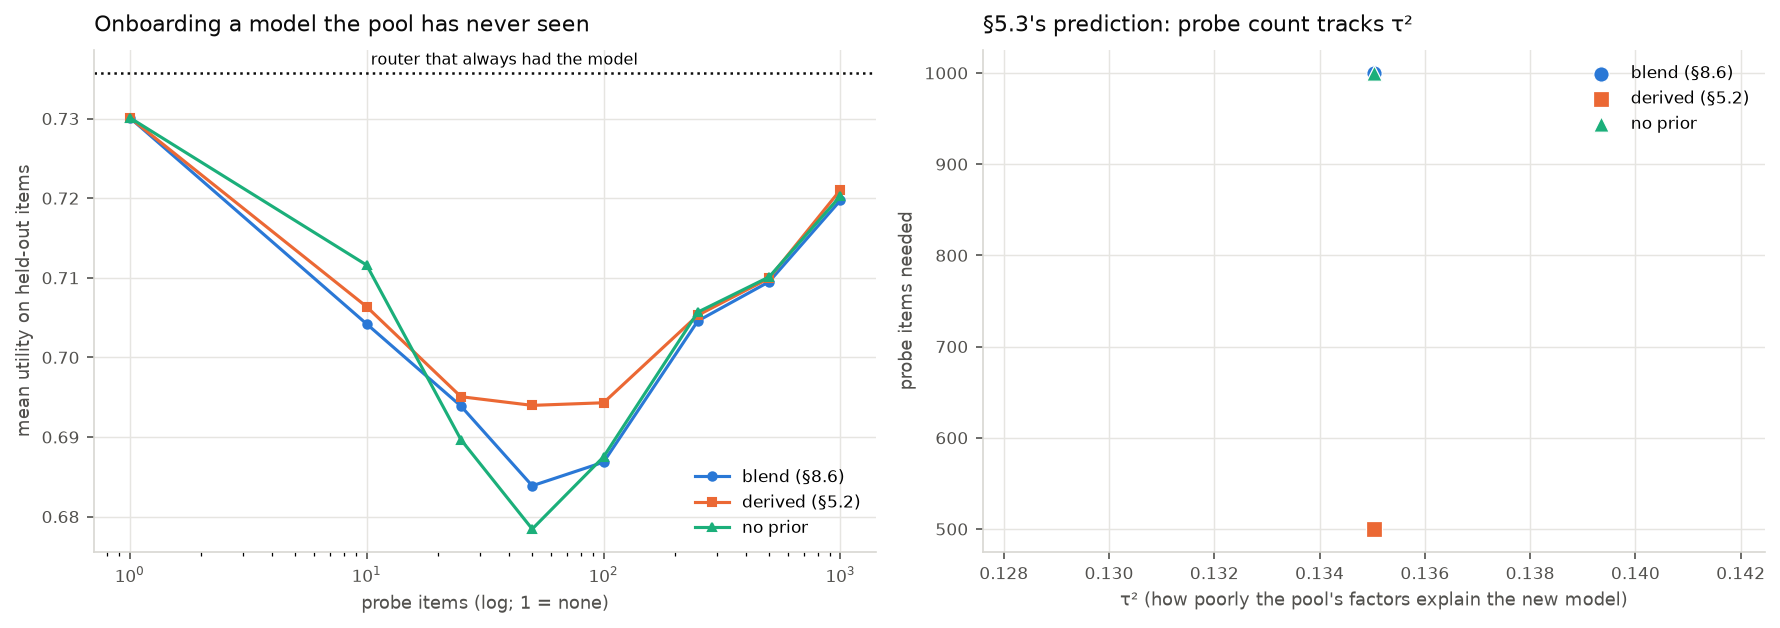

*Left: onboarding curves. Right: probe items needed against τ² — §5.3's prediction that the count should track how poorly the pool explains the new model.*

In [6]:
show("08_coldstart",
     "Left: onboarding curves. Right: probe items needed against τ² — §5.3's prediction that "
     "the count should track how poorly the pool explains the new model.")

Two things in that table are worth stopping on.

**The dip.** Every prior gets *worse* between 10 and 50 probe items than at zero, before
recovering. A partially-learned column is worse than an absent one: the estimate is
confident enough to be selected and wrong enough to hurt. That is a real operational
hazard for FR-15's 24-hour onboarding promise, and it argues for gating a new model on a
minimum probe size rather than making it selectable as soon as it has any data.

**Most models do not matter.** The per-model gaps below show that only one of eleven had
a material onboarding gap at all.

In [7]:
gap = pd.Series(s["onboarding_gap_at_zero_probe"]).sort_values(ascending=False)
need = pd.DataFrame(s["probe_items_needed"])
tau = pd.Series(s["tau2_by_model"])
out = pd.concat([gap.rename("gap at n=0"), need], axis=1).sort_values("gap at n=0", ascending=False)
out

,gap at n=0,blend (§8.6),derived (§5.2),no prior
gpt-4-1106-preview,0.0575,"1,000.0000",500.0000,"1,000.0000"
zero-one-ai/Yi-34B-Chat,0.0046,NaN,NaN,NaN
gpt-3.5-turbo-1106,0.0004,NaN,NaN,NaN
claude-v2,0.0004,NaN,NaN,NaN
WizardLM/WizardLM-13B-V1.2,0.0000,0.0000,0.0000,0.0000
mistralai/mistral-7b-chat,-0.0001,0.0000,0.0000,0.0000
meta/code-llama-instruct-34b-chat,-0.0001,0.0000,0.0000,0.0000
claude-v1,-0.0001,0.0000,0.0000,0.0000
meta/llama-2-70b-chat,-0.0002,0.0000,0.0000,0.0000
claude-instant-v1,-0.0002,0.0000,0.0000,0.0000


In [8]:
mat = s["material_models"]
md(f"""
Only **{', '.join(mat)}** had an onboarding gap worth closing ({gap.iloc[0]:.4f}); every
other model's arrival left the pool's achievable utility essentially unchanged.

For that one model, the priors do differ: **{int(need.loc[mat[0], 'derived (§5.2)'])}** probe
items with the derived prior and **{int(need.loc[mat[0], 'blend (§8.6)'])}** with the informal
blend, against **{int(need.loc[mat[0], 'no prior'])}** with none.
""")
finding("mixed",
        f"The derived prior halves the probe requirement for the one model whose onboarding "
        f"mattered ({int(need.loc[mat[0], 'derived (§5.2)'])} vs "
        f"{int(need.loc[mat[0], 'no prior'])} items), and τ² correlates with probe count at "
        f"{s['tau2_vs_probe_correlation']['derived (§5.2)']:+.2f} — so §5.3's shape is right. "
        f"But the bridge it is derived through explains only 26% of the variance, and n=1 "
        f"material model is not a sample. Directionally supported, not established.")


Only **gpt-4-1106-preview** had an onboarding gap worth closing (0.0575); every
other model's arrival left the pool's achievable utility essentially unchanged.

For that one model, the priors do differ: **500** probe
items with the derived prior and **1000** with the informal
blend, against **1000** with none.


> **MIXED** — The derived prior halves the probe requirement for the one model whose onboarding mattered (500 vs 1000 items), and τ² correlates with probe count at +0.47 — so §5.3's shape is right. But the bridge it is derived through explains only 26% of the variance, and n=1 material model is not a sample. Directionally supported, not established.

In [9]:
md("### τ² against probe count, per prior\n\n" + "\n".join(
    f"- {k}: r = {v:+.3f}" for k, v in s["tau2_vs_probe_correlation"].items())
   + "\n\nPositive correlations mean a model the pool explains poorly needs more probing, "
     "which is the direction §5.3 predicts.")

### τ² against probe count, per prior

- blend (§8.6): r = +0.466
- derived (§5.2): r = +0.466
- no prior: r = +0.466

Positive correlations mean a model the pool explains poorly needs more probing, which is the direction §5.3 predicts.